# Overview

This assignment introduces linear classifiers (perceptrons), nonlinear neural networks, regularization, and visualization of decision boundaries.

All implementation must be done in NumPy **only** (no PyTorch, TensorFlow, JAX, or sklearn for training).


Ensure your code is well-commented and easy to understand.


In [72]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_moons
from sklearn.datasets import load_digits
from sklearn.preprocessing import OneHotEncoder

# Part 1 – Implement a Single Perceptron

## Implement the Perceptron Class

### Class Methods to Implement:

- `__init__(self, input_dim, lr=0.01)`  
  Initialize the weight vector `w` and bias `b`, and set the learning rate `η`.

- `forward(self, X)`  
  Compute the predicted output using the **step activation function**:
  $$
  \hat{y} = f(w^{\top} X + b), \quad
  f(z) =
  \begin{cases}
    1 & \text{if } z > 0 \\
    0 & \text{otherwise}
  \end{cases}
  $$

- `train_step(self, X, y)`  
  Update the weights and bias using the **perceptron learning rule**:
  $$
  w \leftarrow w + \eta (y - \hat{y}) X
  $$
  $$
  b \leftarrow b + \eta (y - \hat{y})
  $$

### Notes:

- $X$ is the input data. In `forward`, handle both single samples `(D,)` and batches `(N, D)`.
- $w$ is the weight vector, $b$ is the bias, and $\eta$ is the learning rate.
- Output $y$ should be `{0, 1}` (matching the data).
- Implement all computations manually using **NumPy**.
- `train_step` performs one update for a **single sample**.


In [73]:
class Perceptron:
  def __init__(self, input_dim, lr=0.1):
    self.lr = lr
    self.w = np.zeros(input_dim) # add input_dim to create zeroed out weights vector
    self.b = 0.0

  def forward(self, x):
    """
    x: numpy array shape (D,) for single sample, or (N, D) for N samples
    returns: 0 or 1 for single sample, or numpy array of 0s and 1s for N samples
    """
    if len(x.shape) == 1: # handle single inputs - if just a vector input the .shape has 1 dimension
      x = x.reshape(1, -1) # reshape into a 1 x D row vector matrix
    out = np.matmul(x, self.w) # numpy .matmul treat weights vector as a column vector on the right
    # and dot product it into all the rows (inputs) of x matrix, outputs a vector of dot products
    out += self.b # add the scalar bias to the vector of outputs
    out = (out >= 0).astype(int) # apply the thresholding function
    # return integer value (1 or 0) of the boolean expression of element >= 0 for all elements
    return out
    
  def train_step(self, x, y):
    """
    Performs a single perceptron update:
    w <- w + lr * (y - y_pred) * x
    b <- b + lr * (y - y_pred)

    Learns on ONE SINGLE POINT
    """
    pred = self.forward(x) # forward pass for prediction
    error = y - pred # find error of prediction (direction of change) - either it is 0, or +1/-1.
    self.b += self.lr * (error)
    self.w += self.lr * (error) * x # since x is a single data point it is just a vector
    # so it can be multiplied by these scalars and add directly to vector of weights

## Test the model on a few sample inputs to ensure that the output is always 0 or 1.


In [74]:
p = Perceptron(input_dim = 2, lr = 0.1)

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([0,0,0,1])   # AND gate

for epoch in range(10):
    for x, y in zip(X, Y):
        p.train_step(x, y)

print("Weights:", p.w)
print("Bias:", p.b)

for x in X:
    print(x, "->", p.forward(x))

Weights: [0.2 0.1]
Bias: [-0.2]
[0 0] -> [0]
[0 1] -> [0]
[1 0] -> [0]
[1 1] -> [1]


## Generate a 2D Toy Dataset

### Task

Generate a simple **2D dataset** for binary classification.

**Requirements:**
- The dataset must be **partially - linearly separable** (meaning a straight line can separate the two classes, but not perfectly). If the data is highly non-linearly separable, the single-layer perceptron will not converge.
- You can use `sklearn.datasets.make_moons` or generate random points manually to experiment.
- Visualize the dataset using a scatter plot to verify partial-linear separability.


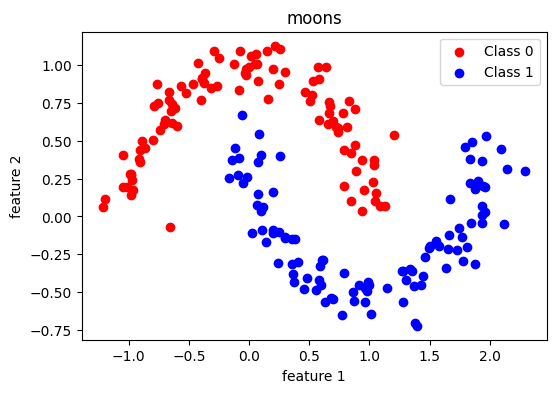

In [75]:
X, y = make_moons(n_samples=200, noise=0.1, random_state=67)

class_0 = X[y == 0] # boolean masks to seperate out classes 0 vs 1
class_1 = X[y == 1]

plt.figure(figsize=(6, 4))
# plot all rows (point values) for class_0 and class_1
plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class 1')
plt.title("moons")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.show()

## Train the Perceptron

### Task

- Train your perceptron on the generated dataset.
- Iterate for multiple **epochs** (passes over the entire dataset).
- Calculate and print the **training accuracy** after each epoch.
- **Expectation**: Since you generated a partially-linearly separable data, the perceptron should reach **>70% accuracy** fairly quickly, but probably doesn't go above 90.


In [76]:
# using test code setup from above
p = Perceptron(input_dim=2, lr=0.1)

for epoch in range(10):
    for x_i, y_i in zip(X, y):
        p.train_step(x_i, y_i)
    # Predict on all data
    preds = p.forward(X).flatten()
    acc = np.mean(preds == y)
    print(f"Epoch {epoch+1}: Training accuracy = {acc*100:.2f}%")

Epoch 1: Training accuracy = 82.50%
Epoch 2: Training accuracy = 82.50%
Epoch 3: Training accuracy = 85.00%
Epoch 4: Training accuracy = 85.00%
Epoch 5: Training accuracy = 87.00%
Epoch 6: Training accuracy = 87.00%
Epoch 7: Training accuracy = 82.50%
Epoch 8: Training accuracy = 86.00%
Epoch 9: Training accuracy = 85.00%
Epoch 10: Training accuracy = 87.00%


## Visualize the Decision Boundary

### Task

- Plot the decision boundary learned by your perceptron along with the data points.
- **Visualizing the Boundary**: Create a meshgrid over the input space, predict the class for every point in the grid, and plot the contours.
- **Observation**: You should see a **straight line** separating the two classes, confirming that the single-layer perceptron is a linear classifier.


### Create a meshgrid

In [77]:
# create extra room in overall grid from bottom and top points to extend visual
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
# xx and yy are meshgrid points to test class predictions, made by quick linspace of 300 points
# I actually tried using 1000x1000 meshgrid but it took too long to evaluate 
# somehow (more than 1min so I quit it)
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
# xx for meshgrid extended x values, yy for meshgrid extended y values

### Evaluate perceptron prediction on grid

In [78]:
Z = []
for i in range(len(xx.flatten())): 
    # loop through all point combinations
    point = np.array([xx.flatten()[i], yy.flatten()[i]])
    # add the point combination output prediction to Z
    Z.append(p.forward(point))
# reshape in the same way it was flattened
Z = np.array(Z).reshape(xx.shape)

### Plot contour

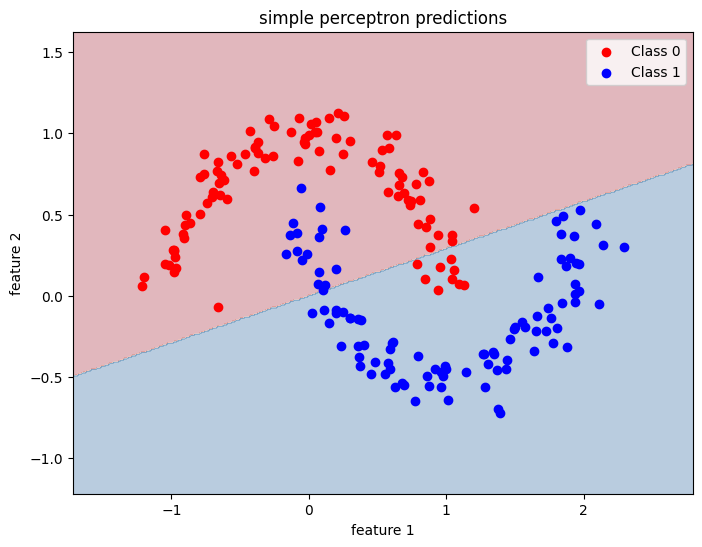

In [79]:
plt.figure(figsize=(8, 6))
# plot mesh grid values with predictions Z
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("simple perceptron predictions")
plt.legend()
plt.show()

# Part 2 – Implement a Two-Layer Sigmoid Network (NumPy Only)

In this part, you will implement and train a **two-layer fully connected neural network** using the **sigmoid activation function**. All computations must be implemented **manually using NumPy** (no automatic differentiation or deep learning frameworks).

---

## Model Definition

The network has the following form:

$$
h = \sigma(x W_1 + b_1)
$$

$$
\hat{y} = \sigma(h W_2 + b_2)
$$

where:

- $x \in \mathbb{R}^{d}$ is the input,
- $W_1 \in \mathbb{R}^{d \times h},\ b_1 \in \mathbb{R}^{h}$,
- $W_2 \in \mathbb{R}^{h \times 1},\ b_2 \in \mathbb{R}$,
- $h$ is the hidden layer dimension,
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the **sigmoid activation function**.

---

## Loss Function

Use **binary cross-entropy (BCE)** as the training loss:

$$
\mathcal{L}_{\text{BCE}} = -\frac{1}{N} \sum_{i=1}^N \Big[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\Big]
$$

- This is suitable for binary classification problems.
- Ensure that the network output $\hat{y}$ is in the range $[0, 1]$ by using a sigmoid activation in the output layer.

---

## Required Methods

Your network class should include at least the following methods:

- `__init__(self, input_dim, hidden_dim, lr)`  
  Initialize weights and biases.

- `forward(self, X)`  
  Compute the forward pass and return the network output.

- `backward(self, X, y)`  
  Compute gradients of all parameters using backpropagation.

- `train(self, X, y, epochs)`  
  Train the network using gradient descent and report the training loss.

- `predict(self, X)`  
  Return predicted class labels (0 or 1) using a **0.5 threshold**.

You may add additional helper functions as needed (e.g., sigmoid, sigmoid derivative, loss, etc).

---

## Training Requirements

- Use **manual gradient descent** with a fixed learning rate.
- Do **not** use any automatic differentiation tools.
- All gradients must be derived and implemented explicitly.

---

### Tasks

- Implement a two-layer neural network with an **arbitrary hidden dimension**.
- Train the network on the **Toy dataset** from before.
- Visualize the learned non-linear decision boundry using a grid-based contour plot like before.
- Train the network on an Image called **Digits** (MNIST like).
- Visualize the loss curves and report your accuracy. 


In [80]:
class NeuralNetwork:
	def __init__(self, input_size, hidden_size, output_size = 1, lr = 0.1):
		self.input_size = input_size
		self.hidden_size = hidden_size
		self.output_size = output_size
		self.lr = lr

		# weight 1 is  a matrix such that when a batch of n inputs 
		# is provided, in dimension batch_size x input_size, the matrix multiplication
		# X * W1 is possible. So that means W1 must be of dimension input_size x hidden_size.
		# this means the matrix multiplication will produce output matrix of batch_size x_hidden_size
		# so every element of the batch has a set of hidden layer inputs. perfect :)
		# continue logic to derive sizes for everything else (wait just saw they were given too)

		# W1: input_size x hidden_size (connects input to hidden layer)
		# initialize weights randomly to prevent symmetry learning issues
		self.W1 = np.random.randn(input_size, hidden_size)
		# b1: hidden_size (bias for each hidden neuron, added after W1 applies)
		self.b1 = np.zeros(self.hidden_size)
		# W2: hidden_size x 1 (connects hidden layer to output neuron)
		self.W2 = np.random.randn(hidden_size, output_size)
		# b2: bias for output neuron
		self.b2 = np.zeros(self.output_size)

	def sigmoid(self, x):
		return 1 / (1 + np.exp(-x))

	def sigmoid_derivative(self, x):
		# derivative of sigmoid = sigmoid(x) * (1 - sigmoid(x))
		s = self.sigmoid(x)
		return s * (1 - s)

	def calculate_loss(self, y_true, y_pred):
		# prevent y_pred from being exactly 0 (rare) for log(0) risk
		# clip it so if its ever exactly 1 or 0 it is fixed to barely not be
		anti_0 = 1e-8
		y_pred = np.clip(y_pred, anti_0, 1 - anti_0)
		# implementation of given equation - element wise operations summed and averaged
		# turns y_true/y_pred dimensions (batch x output)
		# into (batch,) size vector and applying formula,
		# calculates a loss for every prediction part
		sample_losses = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred), axis = 1)
		# averages (batch,) prediction losses into just one scalar
		# making it equal to the total loss of the prediction
		total_loss = np.mean(sample_losses)
		return total_loss

	def forward(self, x):
		if len(x.shape) == 1: # reshape into a 1 x D 'row vector' matrix
			x = x.reshape(1, -1)
		# calculate hidden layer output
		# input "x" (batch x input_size dimension) matrix multiplying
		# weights W1 (input_size x hidden_size dimension)
		# will properly dot product one row of input with each set
		# of hidden layer weights to generate hidden layer outputs for
		# each input sample, z1 = (batch x hidden_size dimension)
		# a set of hidden layer outputs for each input in the batch
		self.z1 = np.matmul(x, self.W1) + self.b1
		# apply sigmoid element-wise
		self.a1 = self.sigmoid(self.z1)
		# multiply batch x hidden size
		# with a hidden size x output to get batch x output, making
		# the z2 be values of output per batch sample
		self.z2 = np.matmul(self.a1, self.W2) + self.b2
		self.pred = self.sigmoid(self.z2) 
		return self.pred

	def backward(self, x, y, learning_rate):
		batch_size = x.shape[0]
		# need to update W1, b1, W2, b2
		# trained values z1, a1, z2, pred are stored in forward
		if len(y.shape) == 1:
			y = y.reshape(-1, 1) # reshape a (batch,) y into (batch x 1)
		# matches all other y which go (batch, input_size)
		# dL/dz2 = dL/dypred * dypred/dz2 = 
		# (ypred-y)/(ypred*(1-ypred)) * (ypred*(1-ypred)) =
		# ypred-y !!!
		dz2 = self.pred - y # dimension batch x output
		# dL/W2 = dL/dypred * dypred/dz2 * dz2/dW2 =
		# (ypred - y) * a1 - note a1 is dimension batch x hidden
		# and the W2 are hidden x output
		# so we want to transform (batch x output) and (batch x hidden) into
		# (hidden x output) so we need to transpose one and maybe rearrange
		# we put a1 first and transpose it so the operation goes
		# (hidden x batch) x (batch x output) = (hidden x output) matching W2
		# this sums up dot product over all batches so divide to scale it down /average it
		dW2 = np.matmul(self.a1.T, dz2) / batch_size
		# dL/db2 = dL/dypred * dypred/dz2 * dz2/db2 =
		# (ypred-y) * 1 = dL/dz2 !
		# but dL/dz2 is shape batch x output and we want
		# bias of (output,) so we average over all batches
		# so sum over axis 0 and divide by batch_size or mean by axis 0.
		db2 = np.sum(dz2, axis = 0) / batch_size # dimension (output,)
		# next we go one layer deeper to find dL/dz1
		# dL/dz1 = dL/dz2 * dz2/da1 * da1/dz1 = 
		# (ypred-y) * W2 * sigmoid_derivative(z1)
		# dimensions are:
		# (batch x output) * (hidden x output) .* (batch x hidden)
		# we want output to match (batch x hidden)
		# we can arrange as:
		# (batch x output) * (output x hidden) .* (batch x hidden)
		dz1 = np.matmul(dz2, self.W2.T) * self.sigmoid_derivative(self.z1) # shape is properly batch x hidden for z1 gradient
		# just like before calculating dW1 and db1 from here is easy
		# we know dz1/dW1 = x
		# dL/dW1 = dL/dz1 * dz1/dW1 = what we calculated * x
		# dimensions are:
		# (batch x hidden) * (batch x input)
		# W1 is dimension (input x hidden)
		# to match we rearrange and transpose x to make (input x batch) * (batch x hidden)
		# average magnitude over all of batch since it gets summed across in dot product once again
		dW1 = np.dot(x.T, dz1) / batch_size # properly (input x hidden)
		# for db1 we note dz1/db1 = 1 once again so
		# dL/db1 = dL/dz1 we calculated * 1
		# but the dimension z1 is (batch x hidden)
		# and our bias dimensions is just (hidden,)
		# so we can average this gradient across all batch samples
		# to get average change for every hidden layer bias
		db1 = np.sum(dz1, axis=0) / batch_size # properly dimension (hidden,) now

		# finally we apply all of these gradients together without any new calculations
		self.W2 -= learning_rate * dW2
		self.b2 -= learning_rate * db2
		self.W1 -= learning_rate * dW1
		self.b1 -= learning_rate * db1

	def train(self, x, y, epochs, learning_rate):
		losslist = []
		for epoch in range(epochs): 
			# loop through epochs count and do forward pass of batch
			pred = self.forward(x)
			# add a loss to loss-list
			loss = self.calculate_loss(y, pred)
			losslist.append(loss)
			print(f"Epoch {epoch+1}/{epochs}: Loss = {loss:.4f}")
			# backward pass and update weights
			self.backward(x, y, learning_rate)
		return losslist
		
	def predict(self, x):
		pred = self.forward(x)
		# different dimesions will generate different predictions
		if self.output_size == 1:
			# binary classifier - 0.5 threshold
			return (pred > 0.5).astype(int).flatten()
		else:
			# multi-class classifier - choose max in list
			# dimension of pred = (batch x output)
			# we want to flatten into (batch x 1)
			# so axis = 1
			return np.argmax(pred, axis=1)

### Train on Toy Dataset

In [81]:
X_toy = X
y_toy = y.reshape(-1, 1)

In [82]:
nn = NeuralNetwork(input_size=2, hidden_size=16, output_size=1, lr=0.1)
losslist = nn.train(X_toy, y_toy, epochs=500, learning_rate=1.0)

Epoch 1/500: Loss = 0.7948
Epoch 2/500: Loss = 0.6668
Epoch 3/500: Loss = 0.5880
Epoch 4/500: Loss = 0.5352
Epoch 5/500: Loss = 0.4980
Epoch 6/500: Loss = 0.4706
Epoch 7/500: Loss = 0.4494
Epoch 8/500: Loss = 0.4326
Epoch 9/500: Loss = 0.4188
Epoch 10/500: Loss = 0.4073
Epoch 11/500: Loss = 0.3975
Epoch 12/500: Loss = 0.3890
Epoch 13/500: Loss = 0.3816
Epoch 14/500: Loss = 0.3750
Epoch 15/500: Loss = 0.3691
Epoch 16/500: Loss = 0.3637
Epoch 17/500: Loss = 0.3588
Epoch 18/500: Loss = 0.3544
Epoch 19/500: Loss = 0.3502
Epoch 20/500: Loss = 0.3464
Epoch 21/500: Loss = 0.3428
Epoch 22/500: Loss = 0.3394
Epoch 23/500: Loss = 0.3362
Epoch 24/500: Loss = 0.3333
Epoch 25/500: Loss = 0.3305
Epoch 26/500: Loss = 0.3278
Epoch 27/500: Loss = 0.3253
Epoch 28/500: Loss = 0.3229
Epoch 29/500: Loss = 0.3206
Epoch 30/500: Loss = 0.3185
Epoch 31/500: Loss = 0.3164
Epoch 32/500: Loss = 0.3145
Epoch 33/500: Loss = 0.3126
Epoch 34/500: Loss = 0.3108
Epoch 35/500: Loss = 0.3091
Epoch 36/500: Loss = 0.3075
E

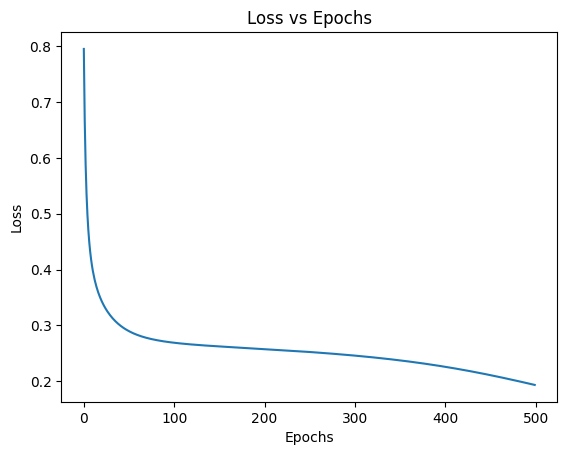

In [83]:
plt.plot(losslist)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

### Calculate the Accuracy of your trained Neural Network on the Toy dataset.


In [84]:
def accuracy(y_true, y_pred):
   print("Accuracy:", (np.where(y_true==y_pred)[0].shape[0] / y_true.shape[0]) * 100, "%")

In [85]:
preds = nn.predict(X_toy)
accuracy(y_toy.flatten(), preds)

Accuracy: 91.0 %


### Visualize the Non-linear decision boundry

In [86]:
x_min, x_max = X_toy[:, 0].min() - 0.5, X_toy[:, 0].max() + 0.5
y_min, y_max = X_toy[:, 1].min() - 0.5, X_toy[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

In [87]:
Z = []
for i in range(len(xx.flatten())):
    point = np.array([xx.flatten()[i], yy.flatten()[i]])
    Z.append(nn.predict(point))
Z = np.array(Z).reshape(xx.shape)

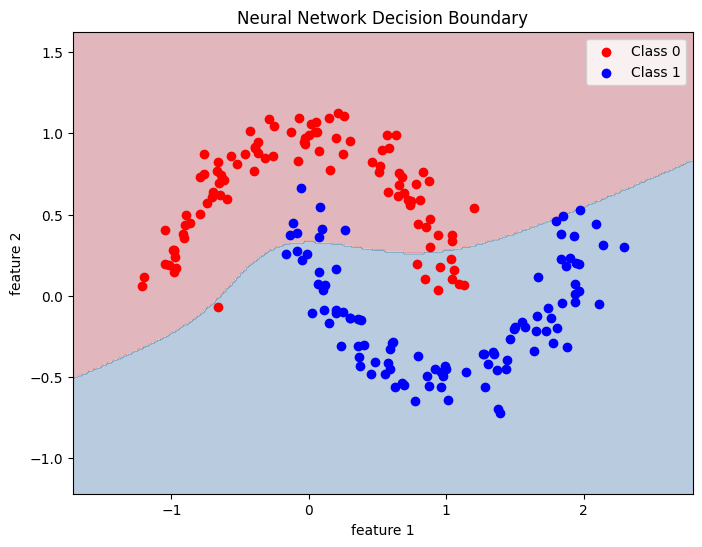

In [88]:
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
plt.scatter(X_toy[y_toy.flatten() == 0, 0], X_toy[y_toy.flatten() == 0, 1], color='red', label='Class 0')
plt.scatter(X_toy[y_toy.flatten() == 1, 0], X_toy[y_toy.flatten() == 1, 1], color='blue', label='Class 1')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Neural Network Decision Boundary")
plt.legend()
plt.show()

### Load the digits dataset from sklearn (MNIST Like).

In [89]:
def normalize(X):
    return X / 16.0

In [90]:
X, y = load_digits(return_X_y=True)
print(f"Image Shape:{X.shape} Label Shape:{y.shape}")

Image Shape:(1797, 64) Label Shape:(1797,)


In [91]:
X = normalize(X)
y = y.reshape(-1,1)
enc = OneHotEncoder(handle_unknown='ignore')
y = enc.fit_transform(y).toarray()
print(f"Image Shape:{X.shape} Label Shape:{y.shape}")

Image Shape:(1797, 64) Label Shape:(1797, 10)


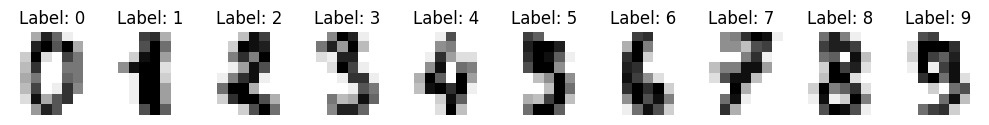

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 10, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Label: {np.argmax(y[i])}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Train your Neural Network

In [93]:
nn = NeuralNetwork(input_size=64, hidden_size=128, output_size=10, lr=0.1)
losslist = nn.train(X, y, epochs=1000, learning_rate=2.0)

Epoch 1/1000: Loss = 2.7830
Epoch 2/1000: Loss = 1.7316
Epoch 3/1000: Loss = 1.6360
Epoch 4/1000: Loss = 1.4581
Epoch 5/1000: Loss = 1.4217
Epoch 6/1000: Loss = 1.4354
Epoch 7/1000: Loss = 0.9668
Epoch 8/1000: Loss = 0.5617
Epoch 9/1000: Loss = 0.4258
Epoch 10/1000: Loss = 0.2847
Epoch 11/1000: Loss = 0.2182
Epoch 12/1000: Loss = 0.1916
Epoch 13/1000: Loss = 0.2160
Epoch 14/1000: Loss = 0.1687
Epoch 15/1000: Loss = 0.1673
Epoch 16/1000: Loss = 0.2311
Epoch 17/1000: Loss = 0.1443
Epoch 18/1000: Loss = 0.1395
Epoch 19/1000: Loss = 0.1558
Epoch 20/1000: Loss = 0.1278
Epoch 21/1000: Loss = 0.1176
Epoch 22/1000: Loss = 0.1178
Epoch 23/1000: Loss = 0.1101
Epoch 24/1000: Loss = 0.1226
Epoch 25/1000: Loss = 0.0997
Epoch 26/1000: Loss = 0.1016
Epoch 27/1000: Loss = 0.0974
Epoch 28/1000: Loss = 0.1086
Epoch 29/1000: Loss = 0.0846
Epoch 30/1000: Loss = 0.0802
Epoch 31/1000: Loss = 0.0826
Epoch 32/1000: Loss = 0.0829
Epoch 33/1000: Loss = 0.0802
Epoch 34/1000: Loss = 0.0857
Epoch 35/1000: Loss = 0

### Plot your training curve

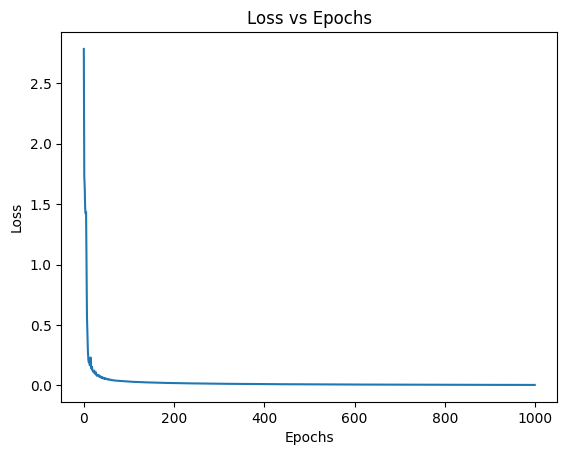

In [94]:
plt.plot(losslist)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

### Calculate the Accuracy of your trained Neural Network on Digits


In [95]:
preds = nn.predict(X)
accuracy(np.argmax(y,axis=1), preds)

Accuracy: 99.88870339454647 %
